In [28]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

from IPython.display import Javascript, display, Audio
from google.colab import output, files

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

In [29]:
from IPython.display import Javascript, display
from google.colab import output
import base64

def record_audio(filename="my_voice.wav", seconds=10):

    js = Javascript("""
    async function recordAudio(seconds) {

        const stream =
            await navigator.mediaDevices.getUserMedia({audio:true});

        const recorder = new MediaRecorder(stream);
        const chunks = [];

        recorder.ondataavailable = event => {
            chunks.push(event.data);
        };

        recorder.start();

        await new Promise(resolve =>
            setTimeout(resolve, seconds * 1000)
        );

        recorder.stop();

        await new Promise(resolve =>
            recorder.onstop = resolve
        );

        stream.getTracks().forEach(track => track.stop());

        const blob = new Blob(chunks, {
            type: 'audio/wav'
        });

        const reader = new FileReader();

        return await new Promise(resolve => {

            reader.onloadend = () =>
                resolve(reader.result.split(',')[1]);

            reader.readAsDataURL(blob);
        });
    }
    """)

    display(js)

    data = output.eval_js(
        f"recordAudio({seconds})"
    )

    audio_bytes = base64.b64decode(data)

    with open(filename, "wb") as f:
        f.write(audio_bytes)

    print("Saved:", filename)

In [30]:
record_audio("my_voice.wav", seconds=5)

<IPython.core.display.Javascript object>

Saved: my_voice.wav


In [31]:
uploaded = files.upload()
audio_file = list(uploaded.keys())[0]
print("Using:", audio_file)

Saving my_voice (2).wav to my_voice (2) (1).wav
Using: my_voice (2) (1).wav


In [32]:
y, sr = librosa.load(
    audio_file,
    sr=16000
)

duration = len(y) / sr

print("Sample rate :", sr)
print("Duration    :", round(duration, 2), "seconds")
print("Samples     :", len(y))

Sample rate : 16000
Duration    : 4.92 seconds
Samples     : 78720


/tmp/ipykernel_1740/2467966800.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


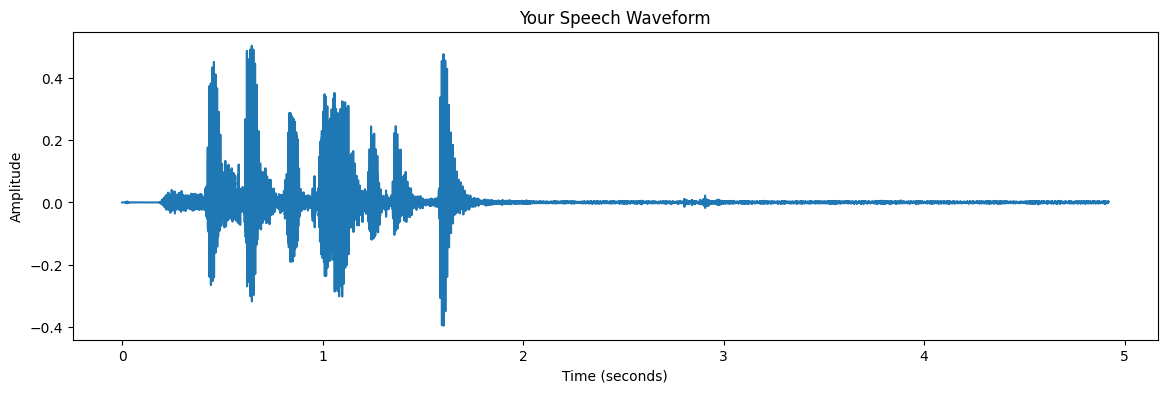

In [33]:
time = np.arange(len(y)) / sr

plt.figure(figsize=(14, 4))

plt.plot(time, y)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Your Speech Waveform")

plt.show()

In [34]:
intervals = librosa.effects.split(
    y,
    top_db=30
)

speech_duration = sum(
    end - start
    for start, end in intervals
) / sr

silence_duration = duration - speech_duration

print("Total duration   :", round(duration, 3), "s")
print("Speech duration  :", round(speech_duration, 3), "s")
print("Silence duration :", round(silence_duration, 3), "s")

Total duration   : 4.92 s
Speech duration  : 1.632 s
Silence duration : 3.288 s


In [35]:
speech_ratio = speech_duration / duration
pause_ratio = silence_duration / duration

print("Speech ratio :", round(speech_ratio, 3))
print("Pause ratio  :", round(pause_ratio, 3))

Speech ratio : 0.332
Pause ratio  : 0.668


In [36]:
pauses = []

for i in range(len(intervals) - 1):

    current_end = intervals[i][1]
    next_start = intervals[i + 1][0]

    pause = (next_start - current_end) / sr

    pauses.append(pause)

pauses = np.array(pauses)

print("Number of pauses:", len(pauses))

if len(pauses) > 0:

    print("Mean pause     :", round(np.mean(pauses), 4), "s")
    print("Variance       :", round(np.var(pauses), 6))
    print("Median pause   :", round(np.median(pauses), 4), "s")
    print("IQR            :",
          round(
              np.percentile(pauses, 75)
              - np.percentile(pauses, 25),
              4
          ),
          "s")

Number of pauses: 0


In [37]:
if len(pauses) > 0:

    mean_pause = np.mean(pauses)

    variance_pause = np.var(pauses)

    iqr_pause = (
        np.percentile(pauses, 75)
        -
        np.percentile(pauses, 25)
    )

else:

    mean_pause = 0
    variance_pause = 0
    iqr_pause = 0


features = np.array([
    speech_ratio,
    pause_ratio,
    mean_pause,
    variance_pause,
    iqr_pause
])

print("Features:")
print(features)

Features:
[0.33170732 0.66829268 0.         0.         0.        ]


In [38]:
rng = np.random.default_rng(42)

N = 200

# --------------------------------
# Simulated HEALTH speakers
# --------------------------------

health_speech_ratio = rng.normal(
    0.80, 0.07, N
)

health_pause_ratio = rng.normal(
    0.20, 0.07, N
)

health_mean_pause = rng.normal(
    0.25, 0.08, N
)

health_variance = rng.normal(
    0.015, 0.008, N
)

health_iqr = rng.normal(
    0.12, 0.04, N
)


# --------------------------------
# Simulated DEPRESSION speakers
# --------------------------------

dep_speech_ratio = rng.normal(
    0.65, 0.08, N
)

dep_pause_ratio = rng.normal(
    0.35, 0.08, N
)

dep_mean_pause = rng.normal(
    0.40, 0.12, N
)

dep_variance = rng.normal(
    0.025, 0.010, N
)

dep_iqr = rng.normal(
    0.18, 0.05, N
)

In [39]:
X_health = np.column_stack([
    health_speech_ratio,
    health_pause_ratio,
    health_mean_pause,
    health_variance,
    health_iqr
])

X_dep = np.column_stack([
    dep_speech_ratio,
    dep_pause_ratio,
    dep_mean_pause,
    dep_variance,
    dep_iqr
])

X_train = np.vstack([
    X_health,
    X_dep
])

y_train = np.concatenate([
    np.zeros(N),   # Health
    np.ones(N)     # Depression
])

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

X shape: (400, 5)
y shape: (400,)


In [40]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

In [41]:
kernel = RBF(
    length_scale=1.0,
    length_scale_bounds=(0.5, 100)
)

gpc = GaussianProcessClassifier(
    kernel=kernel,
    random_state=0
)

print("GPC created!")

GPC created!


In [42]:
gpc.fit(
    X_scaled,
    y_train
)

print("GPC trained successfully!")

GPC trained successfully!


In [43]:
features

array([0.33170732, 0.66829268, 0.        , 0.        , 0.        ])

In [44]:
my_features_scaled = scaler.transform(
    features.reshape(1, -1)
)

In [45]:
prediction = gpc.predict(
    my_features_scaled
)

probabilities = gpc.predict_proba(
    my_features_scaled
)

print("Prediction:", prediction)
print("Probabilities:", probabilities)

Prediction: [1.]
Probabilities: [[0.47041048 0.52958952]]


In [46]:
if prediction[0] == 0:

    print("Experimental model output: HEALTH / CONTROL")

else:

    print("Experimental model output: DEPRESSION GROUP")

Experimental model output: DEPRESSION GROUP


In [47]:
print(
    "Health probability     :",
    round(probabilities[0][0] * 100, 2),
    "%"
)

print(
    "Depression probability :",
    round(probabilities[0][1] * 100, 2),
    "%"
)

Health probability     : 47.04 %
Depression probability : 52.96 %
